In [2]:
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

# Load the model and data
clf = joblib.load('asl_svm_model.pkl')
df = pd.read_csv('asl_landmarks.csv')

# Split the data exactly as you did during training
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Generate predictions
y_pred = clf.predict(X_test)
labels = sorted(df['label'].unique())


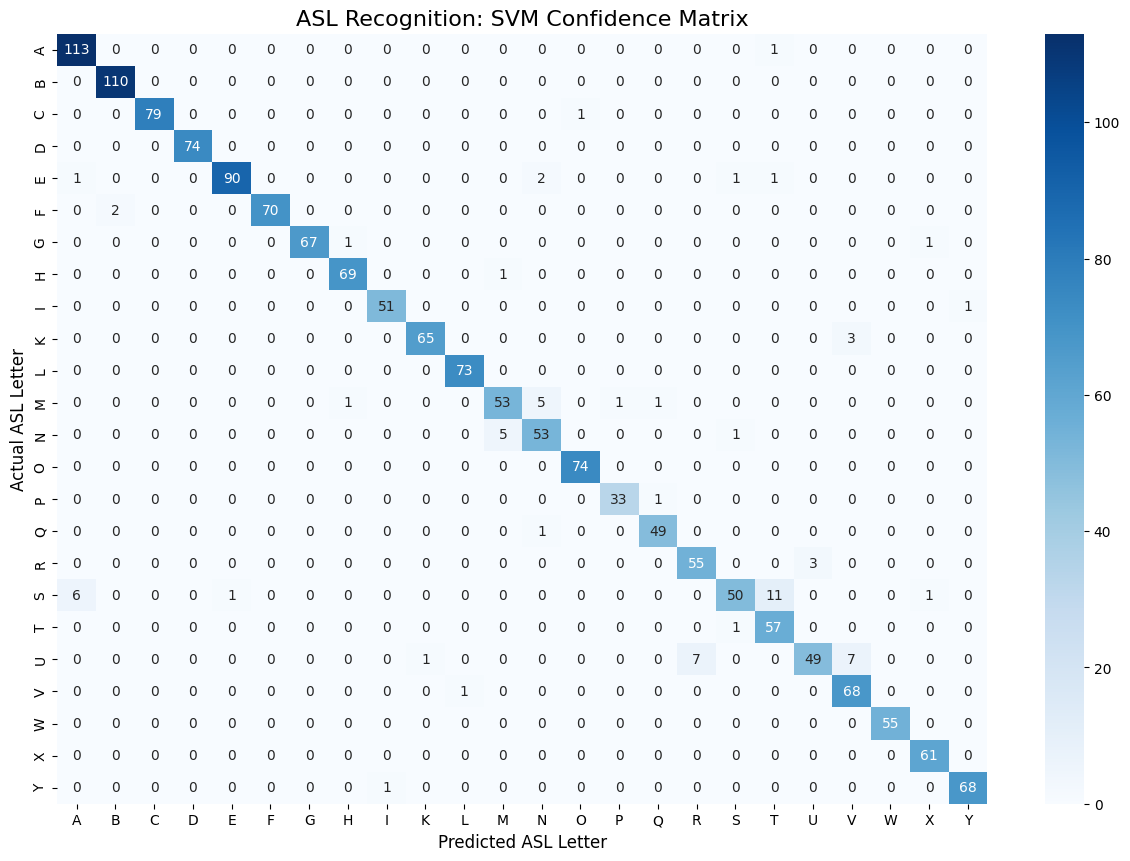

In [4]:
# Create the raw confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=labels)

# Initialize the plot
plt.figure(figsize=(15, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

# Labeling for clarity
plt.title('ASL Recognition: SVM Confidence Matrix', fontsize=16)
plt.xlabel('Predicted ASL Letter', fontsize=12)
plt.ylabel('Actual ASL Letter', fontsize=12)
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()